In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df= pd.read_csv("D:/projects/AI_ML_LEARNING/placement (1).csv")
print(df.to_string())


    Unnamed: 0  cgpa     iq  placement
0            0   6.8  123.0          1
1            1   5.9  106.0          0
2            2   5.3  121.0          0
3            3   7.4  132.0          1
4            4   5.8  142.0          0
5            5   7.1   48.0          1
6            6   5.7  143.0          0
7            7   5.0   63.0          0
8            8   6.1  156.0          0
9            9   5.1   66.0          0
10          10   6.0   45.0          1
11          11   6.9  138.0          1
12          12   5.4  139.0          0
13          13   6.4  116.0          1
14          14   6.1  103.0          0
15          15   5.1  176.0          0
16          16   5.2  224.0          0
17          17   3.3  183.0          0
18          18   4.0  100.0          0
19          19   5.2  132.0          0
20          20   6.6  120.0          1
21          21   7.1  151.0          1
22          22   4.9  120.0          0
23          23   4.7   87.0          0
24          24   4.7  121

Text(0.5, 1.0, 'CG VS IQ')

Text(0, 0.5, 'IQ')

Text(0.5, 0, 'CGPA')

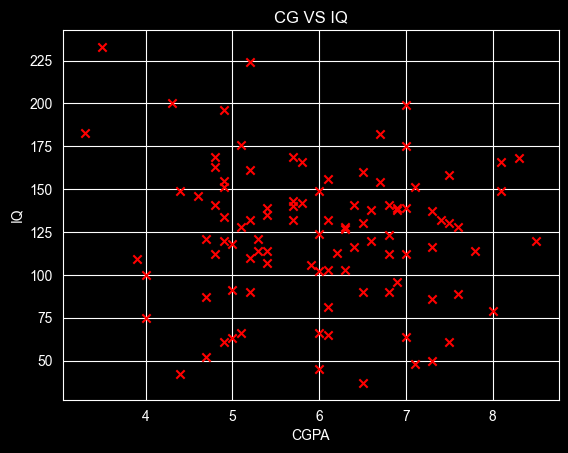

In [3]:
x= np.array(df["cgpa"])
y= np.array(df["iq"])
# Plot the data points
plt.scatter(x, y, marker='x', c='r')
# Set the title
plt.title("CG VS IQ")
# Set the y-axis label
plt.ylabel('IQ')
plt.xlabel('CGPA')
# Set the x-axis label
plt.show()

In [4]:

def compute_cost_function_model_output(x, y, w, b):
    m = x.shape[0]
    cost = 0
    for i in range(m):
        f_wb = w * x[i] + b
        cost = cost+(f_wb - y[i]) ** 2
    total_cost = (1 / (2 * m)) * cost
    return total_cost

#end of cost analysis function
#start of gradient decent
def compute_gradiend(x, y, w, b):
    m= x.shape[0]
    d_dw= 0
    d_db= 0
    for i in range(m):
        f_wb = w * x[i] + b
        d_dwi= (f_wb - y[i])* x[i]
        d_dbi= (f_wb - y[i])
        d_dw += d_dwi
        d_db += d_dbi
    d_dw/=m
    d_db/=m
    return d_dw,d_db
w_values = []
cost_values = []

for w in range(-50, 51):
    cost = compute_cost_function_model_output(x, y, w, b)

    w_values.append(w)
    cost_values.append(cost)

plt.plot(w_values, cost_values)
plt.xlabel("w")
plt.ylabel("Cost")
plt.title("Cost Function")
plt.show()

NameError: name 'train_x' is not defined

In [ ]:
import math, copy
def gradient_descent(x, y, w_in, b_in, alpha, num_iters, cost_function, gradient_function):

    J_history = []
    p_history = []
    b = b_in
    w = w_in

    for i in range(num_iters):
        # Calculate the gradient and update the parameters using gradient_function
        dj_dw, dj_db = gradient_function(x, y, w , b)

        # Update Parameters using equation (3) above
        b = b - alpha * dj_db
        w = w - alpha * dj_dw

        # Save cost J at each iteration
        if i<100000:      # prevent resource exhaustion
            J_history.append(compute_cost_function_model_output(x, y, w , b))
            p_history.append([w,b])

    return w, b, J_history, p_history #return w and J,w history for graphing
# initialize parameters
w_init = 0
b_init = 0
# some gradient descent settings
iterations = 10000
tmp_alpha = 1.0e-2
# run gradient descent
w_final, b_final, J_hist, p_hist = gradient_descent(train_x ,train_y, w_init, b_init, tmp_alpha, iterations, compute_cost_function_model_output, compute_gradiend)
print(f"(w,b) found by gradient descent: ({w_final:8.4f},{b_final:8.4f})")

In [ ]:
# plot cost versus iteration
fig, (ax1, ax2) = plt.subplots(1, 2, constrained_layout=True, figsize=(12,4))
ax1.plot(J_hist[:100])
ax2.plot(1000 + np.arange(len(J_hist[1000:])), J_hist[1000:])
ax1.set_title("Cost vs. iteration(start)");  ax2.set_title("Cost vs. iteration (end)")
ax1.set_ylabel('Cost')            ;  ax2.set_ylabel('Cost')
ax1.set_xlabel('iteration step')  ;  ax2.set_xlabel('iteration step')
plt.show()

In [ ]:
fig, ax = plt.subplots(1,1, figsize=(12, 6))
plt_contour_wgrad(train_x, train_y, p_hist, ax)